#  Practica N° 2: Algoritmos Genéticos
### **UNIDAD: 2**
### **Carrera:** Tecnicatura Superior en Ciencia de Datos e IA
### **Institución:** IFTS 33 - UOCRA
### **Profesor:** Andres Allievi
## **Alumna**: Chino Priscila
---

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [1]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

## Si usan PyGAD:

El Jefe de Obra Virtual está optimizando...
------------------------------
RESULTADO DE LA EVOLUCIÓN:
Mejor Fitness: 0.043478
Tiempo Total de Obra: 23.00 días
Días de inicio por tarea: [10  1 16  6 18  1  8 21 14 21]
------------------------------


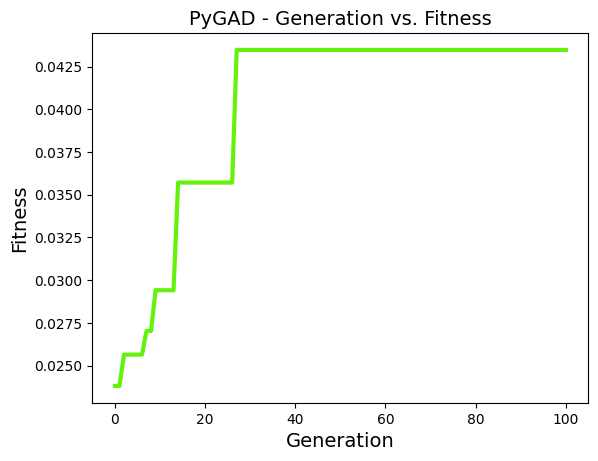

In [26]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

# --- PASO 1: MODELADO DE DATOS ---
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

# --- PASO 2 Y 3: DEFINICIÓN DEL CROMOSOMA Y FUNCIÓN DE FITNESS --- EVALUAMOS SOLUCIONES
def fitness_func(ga_instance, solution, solution_idx):
  #ga_instance → configuracion del algoritmo genetico
  #solution →  solución especifica que el algoritmo esta evaluando en ese preciso momento.
     # Vendria a ser el cromosoma porque en un vector tiene los "Días de inicio" para cada tarea
  #solution_idx → indice de la solucion

    dias_inicio = np.round(solution).astype(int) # ↠ ej:toma una solución y redondea los valores a números enteros,
                                                 # asegurando que sean interpretados como ese tipo de dato.

    # Calculamos el día de finalización de cada tarea
    tiempos_fin = [dias_inicio[i] + TASAS_OBRA[i][0] for i in range(NUM_TAREAS)]
    dias_totales = max(tiempos_fin) # El "Makespan" (duracion del cronograma)

    # Verificación de la restricción de 10 operarios (Cuidado de no "romper" la regla)
    # Creamos un calendario para sumar operarios por día
    uso_diario = np.zeros(max(200, dias_totales + 1))

    for i in range(NUM_TAREAS):
        inicio = max(0, dias_inicio[i])
        fin = tiempos_fin[i]
        uso_diario[inicio:fin] += TASAS_OBRA[i][1]

    # PENALIZACIÓN DRÁSTICA: Si un día sobran operarios, el fitness cae al suelo
    if np.max(uso_diario) > MAX_OPERARIOS:
        return 0.0001

    # OBJETIVO: Minimizar tiempo. Fitness = 1 / DíasTotales
    return 1.0 / dias_totales # Va alimentando el ga_instance para mejorarlo

# --- PASO 4: CONFIGURACIÓN DEL GA ---
ga_instance = pygad.GA(            # Creamos los individuos
    num_generations=100,           # Ciclos de evolución
    sol_per_pop=50,                # Población total, en cada ciclo de evolución.
    num_parents_mating=25,         # 25 mejores padres se reproducen para crear 25 hijos
    num_genes=NUM_TAREAS,          # 10 tareas
    fitness_func=fitness_func, #↠ trae el puntaje, para generar al hijo.

    gene_space={'low': 0, 'high': 60}, # Del dia 0 al 60 pueden iniciar las tareas.

    parent_selection_type="tournament", # Elige a los mejores de forma competitiva
    crossover_type="single_point",      # Como se combinan las soluciones para crear descendencia.
    mutation_percent_genes=10, # cambiara el dia de inicio de una sola tareas para buscar nuevas soluciones
    keep_parents=2             #tome dos mejores padres, sin cruzarlo ni mutarlos
)

# --- PASO 5: EJECUCIÓN Y MONITOREO ---
print("El Jefe de Obra Virtual está optimizando...")
ga_instance.run() #↠ ejecuta el código

# --- PASO 6: ANÁLISIS DE RESULTADOS --- TOMA LA MEJOR SOLUCION DE LA GNERACION 100
solution, solution_fitness, solution_idx = ga_instance.best_solution() # metodo que devuelve tres cosas
#de una sola vez: la mejor solución, su fitness, y su índice en la población.

print("-" * 30)
print(f"RESULTADO DE LA EVOLUCIÓN:")
print(f"Mejor Fitness: {solution_fitness:.6f}")
print(f"Tiempo Total de Obra: {1.0 / solution_fitness:.2f} días")
print(f"Días de inicio por tarea: {np.round(solution).astype(int)}")
print("-" * 30)

# Verificación visual de la optimización
ga_instance.plot_fitness();